<a href="https://colab.research.google.com/github/josephza01/AI-work/blob/main/AIdes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    DECISION TREE CLASSIFICATION PROJECT
Loading iris dataset...
Dataset shape: (150, 4)
Number of classes: 3

Dataset info:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000

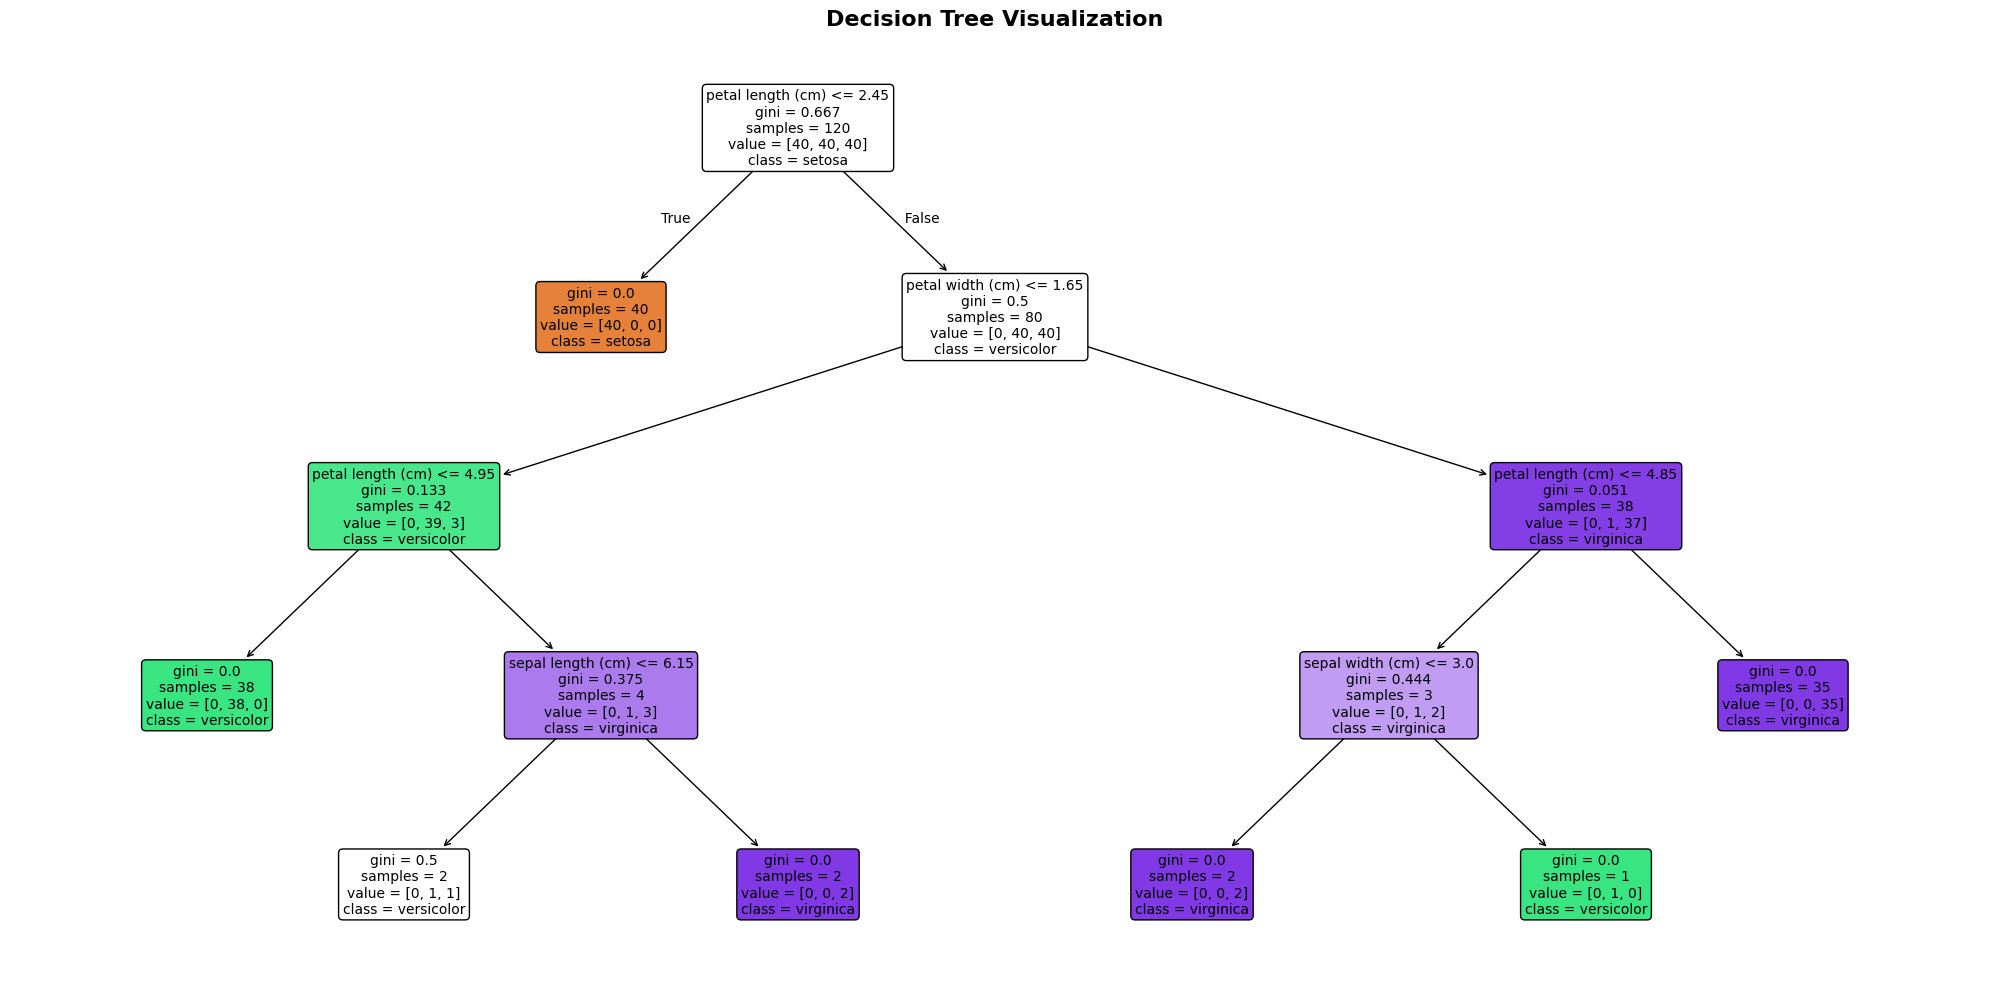


Generating Feature Importance Plot...


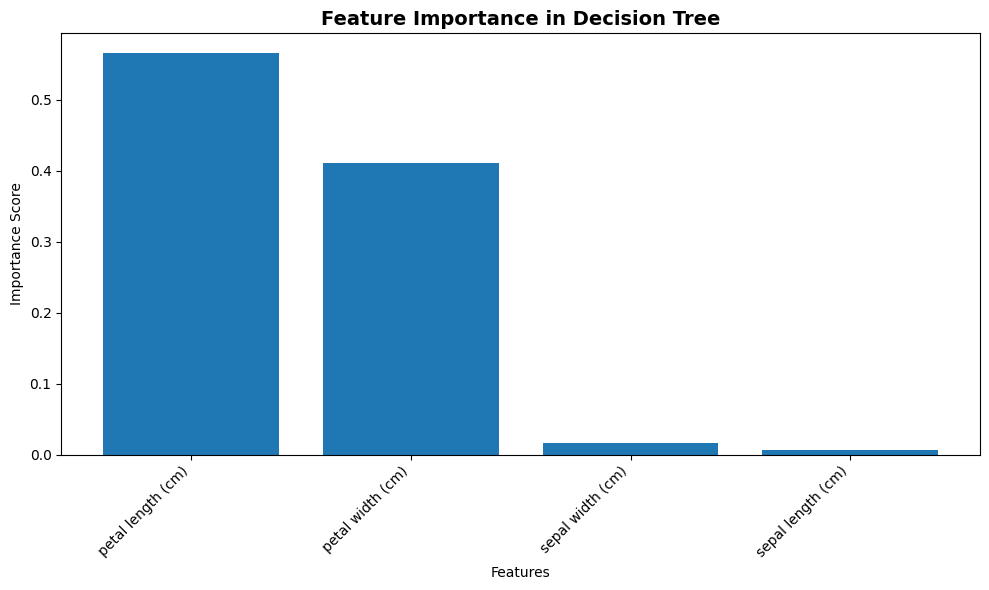


Feature Importance Ranking:
1. petal length (cm): 0.5656
2. petal width (cm): 0.4112
3. sepal width (cm): 0.0169
4. sepal length (cm): 0.0063

Generating Confusion Matrix Heatmap...


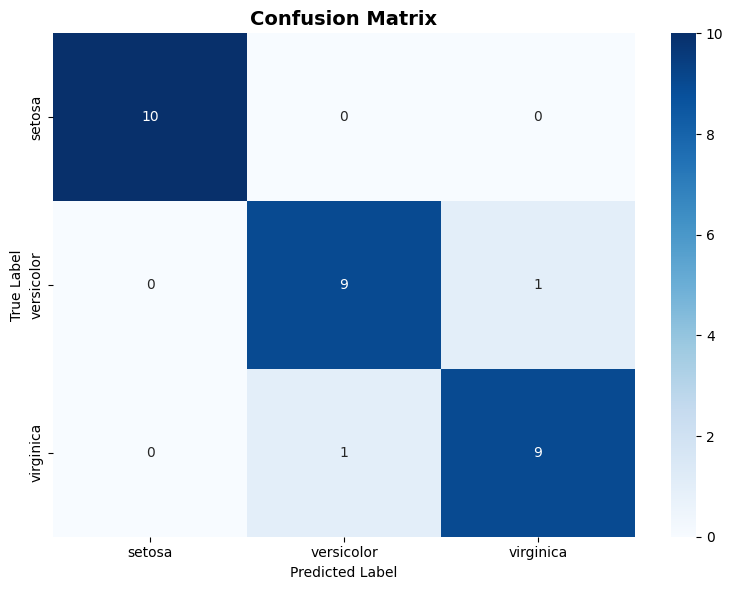


    PROJECT COMPLETED SUCCESSFULLY!


In [2]:
"""
Decision Tree Classification Project
This project demonstrates decision tree implementation for classification tasks
including data preparation, model training, visualization, and evaluation.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

class DecisionTreeProject:
    """Decision Tree Classification Project Class"""

    def __init__(self, dataset_type='iris'):
        """
        Initialize the Decision Tree project

        Parameters:
        -----------
        dataset_type : str
            Type of dataset to use ('iris' or 'custom')
        """
        self.dataset_type = dataset_type
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.model = None
        self.best_model = None
        self.feature_names = None
        self.target_names = None

    def load_data(self):
        """Load and prepare the dataset"""
        print(f"Loading {self.dataset_type} dataset...")

        if self.dataset_type == 'iris':
            # Load Iris dataset
            data = load_iris()
            X = data.data
            y = data.target
            self.feature_names = data.feature_names
            self.target_names = data.target_names

        elif self.dataset_type == 'custom':
            # Generate custom classification dataset
            X, y = make_classification(
                n_samples=1000,
                n_features=10,
                n_informative=5,
                n_redundant=2,
                n_classes=3,
                n_clusters_per_class=2,
                random_state=42
            )
            self.feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
            self.target_names = ['Class_0', 'Class_1', 'Class_2']

        # Create DataFrame for better visualization
        self.df = pd.DataFrame(X, columns=self.feature_names)
        self.df['target'] = y

        print(f"Dataset shape: {X.shape}")
        print(f"Number of classes: {len(np.unique(y))}")
        print(f"\nDataset info:")
        print(self.df.describe())

        return X, y

    def split_data(self, X, y, test_size=0.2):
        """Split data into training and testing sets"""
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )

        print(f"\nTraining set size: {self.X_train.shape[0]}")
        print(f"Testing set size: {self.X_test.shape[0]}")

    def train_model(self, max_depth=3, min_samples_split=2, min_samples_leaf=1):
        """
        Train the Decision Tree model

        Parameters:
        -----------
        max_depth : int
            Maximum depth of the tree
        min_samples_split : int
            Minimum samples required to split a node
        min_samples_leaf : int
            Minimum samples required at a leaf node
        """
        print("\n" + "="*50)
        print("Training Decision Tree Model...")
        print("="*50)

        self.model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

        self.model.fit(self.X_train, self.y_train)

        # Training accuracy
        train_pred = self.model.predict(self.X_train)
        train_accuracy = accuracy_score(self.y_train, train_pred)

        # Testing accuracy
        test_pred = self.model.predict(self.X_test)
        test_accuracy = accuracy_score(self.y_test, test_pred)

        print(f"\nModel Parameters:")
        print(f"  Max Depth: {max_depth}")
        print(f"  Min Samples Split: {min_samples_split}")
        print(f"  Min Samples Leaf: {min_samples_leaf}")
        print(f"\nTraining Accuracy: {train_accuracy:.4f}")
        print(f"Testing Accuracy: {test_accuracy:.4f}")

        return self.model

    def evaluate_model(self):
        """Evaluate the model performance"""
        print("\n" + "="*50)
        print("Model Evaluation")
        print("="*50)

        # Predictions
        y_pred = self.model.predict(self.X_test)

        # Metrics
        accuracy = accuracy_score(self.y_test, y_pred)
        precision = precision_score(self.y_test, y_pred, average='weighted')
        recall = recall_score(self.y_test, y_pred, average='weighted')
        f1 = f1_score(self.y_test, y_pred, average='weighted')

        print(f"\nAccuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}")

        # Classification Report
        print("\n" + "-"*50)
        print("Classification Report:")
        print("-"*50)
        print(classification_report(self.y_test, y_pred,
        target_names=self.target_names))

        # Confusion Matrix
        cm = confusion_matrix(self.y_test, y_pred)
        print("\nConfusion Matrix:")
        print(cm)

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'confusion_matrix': cm
        }

    def cross_validation(self, cv=5):
        """Perform cross-validation"""
        print("\n" + "="*50)
        print(f"Performing {cv}-Fold Cross-Validation...")
        print("="*50)

        scores = cross_val_score(self.model, self.X_train, self.y_train,
        cv=cv, scoring='accuracy')

        print(f"\nCross-validation scores: {scores}")
        print(f"Mean CV Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

        return scores

    def hyperparameter_tuning(self):
        """Perform hyperparameter tuning using GridSearchCV"""
        print("\n" + "="*50)
        print("Hyperparameter Tuning...")
        print("="*50)

        param_grid = {
            'max_depth': [2, 3, 4, 5, 6, 7, 8],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 4, 8],
            'criterion': ['gini', 'entropy']
        }

        grid_search = GridSearchCV(
            DecisionTreeClassifier(random_state=42),
            param_grid,
            cv=5,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )

        grid_search.fit(self.X_train, self.y_train)

        print(f"\nBest Parameters: {grid_search.best_params_}")
        print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

        # Train with best parameters
        self.best_model = grid_search.best_estimator_
        test_accuracy = self.best_model.score(self.X_test, self.y_test)
        print(f"Test Accuracy with Best Model: {test_accuracy:.4f}")

        return grid_search.best_params_

    def visualize_tree(self, figsize=(20, 10), save_path=None):
        """Visualize the decision tree"""
        print("\nGenerating Decision Tree Visualization...")

        plt.figure(figsize=figsize)
        plot_tree(
            self.model,
            feature_names=self.feature_names,
            class_names=self.target_names,
            filled=True,
            rounded=True,
            fontsize=10
        )
        plt.title("Decision Tree Visualization", fontsize=16, fontweight='bold')

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Tree visualization saved to {save_path}")

        plt.tight_layout()
        plt.show()

    def plot_feature_importance(self):
        """Plot feature importance"""
        print("\nGenerating Feature Importance Plot...")

        feature_importance = self.model.feature_importances_
        indices = np.argsort(feature_importance)[::-1]

        plt.figure(figsize=(10, 6))
        plt.title("Feature Importance in Decision Tree", fontsize=14, fontweight='bold')
        plt.bar(range(len(feature_importance)), feature_importance[indices])
        plt.xticks(range(len(feature_importance)),
        [self.feature_names[i] for i in indices], rotation=45, ha='right')
        plt.ylabel('Importance Score')
        plt.xlabel('Features')
        plt.tight_layout()
        plt.show()

        # Print feature importance
        print("\nFeature Importance Ranking:")
        for i, idx in enumerate(indices):
            print(f"{i+1}. {self.feature_names[idx]}: {feature_importance[idx]:.4f}")

    def plot_confusion_matrix(self, metrics):
        """Plot confusion matrix heatmap"""
        print("\nGenerating Confusion Matrix Heatmap...")

        plt.figure(figsize=(8, 6))
        sns.heatmap(
            metrics['confusion_matrix'],
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=self.target_names,
            yticklabels=self.target_names
        )
        plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()

    def get_tree_info(self):
        """Get information about the trained tree"""
        print("\n" + "="*50)
        print("Decision Tree Information")
        print("="*50)

        print(f"\nTree Depth: {self.model.get_depth()}")
        print(f"Number of Leaves: {self.model.get_n_leaves()}")
        print(f"Number of Features: {self.model.n_features_in_}")
        print(f"Number of Classes: {self.model.n_classes_}")


def main():
    """Main function to run the Decision Tree project"""

    print("="*60)
    print("    DECISION TREE CLASSIFICATION PROJECT")
    print("="*60)

    # Initialize project with Iris dataset
    project = DecisionTreeProject(dataset_type='iris')

    # Load data
    X, y = project.load_data()

    # Split data
    project.split_data(X, y, test_size=0.2)

    # Train model
    project.train_model(max_depth=4, min_samples_split=2, min_samples_leaf=1)

    # Evaluate model
    metrics = project.evaluate_model()

    # Cross-validation
    project.cross_validation(cv=5)

    # Get tree information
    project.get_tree_info()

    # Visualizations
    print("\n" + "="*50)
    print("Generating Visualizations...")
    print("="*50)

    project.visualize_tree(figsize=(20, 10))
    project.plot_feature_importance()
    project.plot_confusion_matrix(metrics)

    # Hyperparameter tuning (optional - uncomment to run)
    # print("\n" + "="*50)
    # print("Starting Hyperparameter Tuning...")
    # print("="*50)
    # best_params = project.hyperparameter_tuning()

    print("\n" + "="*60)
    print("    PROJECT COMPLETED SUCCESSFULLY!")
    print("="*60)


if __name__ == "__main__":
    main()
